Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Running pairwise ICP experiments

Experiments:
   Threshold InitialGuess  InitFitness  InitRMSE  FinalFitness  FinalRMSE  \
0       0.02     Identity     0.845421  0.010309      0.849456   0.010272   
1       0.02       Random     0.005381  0.015538      0.006550   0.014534   
2       0.02       RANSAC     0.845713  0.010444      0.849573   0.010274   
3       0.05     Identity     0.980875  0.014206      0.981050   0.014173   
4       0.05       Random     0.010528  0.033840      0.011697   0.031992   
5       0.05       RANSAC     0.980875  0.014212      0.981050   0.014173   
6       0.10     Identity     0.995964  0.016349      0.996081   0.016373   
7       0.10       Random     0.036612  0.069484      0.053164   0.060793   
8       0.10       RANSAC     0.996081  0.016572      0.996023   0.016351   

       Diff  

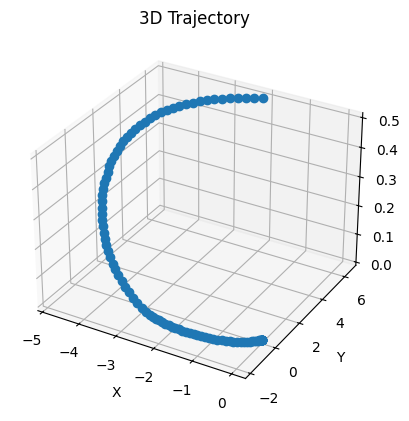

Saved to X:/Projects/CV/Assignment 2/2022484_trajectory.csv


In [ ]:
import os
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ortho_group
import copy
import random

random.seed(2022484)
np.random.seed(2022484)

# Load .pcd files from folder
def LoadPCDs(Folder, VoxelSize=0.02):
    Files = sorted([os.path.join(Folder, f) for f in os.listdir(Folder) if f.endswith('.pcd')])
    PCDs = []
    for F in Files:
        P = o3d.io.read_point_cloud(F)
        P = P.voxel_down_sample(VoxelSize)
        P.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=VoxelSize*2.0, max_nn=30))
        PCDs.append(P)
    return PCDs

# Downsample and compute FPFH
def PreprocessPCD(PCD, VoxelSize=0.02):
    Down = PCD.voxel_down_sample(VoxelSize)
    Down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=VoxelSize*2.0, max_nn=30))
    FeatureRad = VoxelSize * 5.0
    FPFH = o3d.pipelines.registration.compute_fpfh_feature(
        Down,
        o3d.geometry.KDTreeSearchParamHybrid(radius=FeatureRad, max_nn=100)
    )
    return Down, FPFH

# Return random orthonormal guess
def RandomGuess():
    R = ortho_group.rvs(3)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = np.random.uniform(-0.5, 0.5, size=(3,))
    return T

def IdentityGuess():
    return np.eye(4)

def RansacGuess(SrcDown, TgtDown, SrcFPFH, TgtFPFH, VoxelSize=0.02):
    Thresh = VoxelSize * 1.5
    Res = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        SrcDown, TgtDown, SrcFPFH, TgtFPFH,
        mutual_filter=True,
        max_correspondence_distance=Thresh,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        ransac_n=4,
        checkers=[
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(Thresh)
        ],
        criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
    )
    return Res.transformation

def EvalMetrics(Src, Tgt, Trans, Thresh):
    Eval = o3d.pipelines.registration.evaluate_registration(Src, Tgt, Thresh, Trans)
    return Eval.fitness, Eval.inlier_rmse

def PairICP(Src, Tgt, InitTrans, Thresh, MaxIter=50):
    Res = o3d.pipelines.registration.registration_icp(
        Src, Tgt, Thresh, InitTrans,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=MaxIter)
    )
    return Res

def RunExperiments(Src, Tgt, VoxelSize=0.02):
    ThreshList = [0.02, 0.05, 0.1]
    GuessDict = {"Identity": IdentityGuess, "Random": RandomGuess, "RANSAC": None}
    SrcDown, SrcFPFH = PreprocessPCD(Src, VoxelSize)
    TgtDown, TgtFPFH = PreprocessPCD(Tgt, VoxelSize)
    Results = []
    for Thresh in ThreshList:
        for Name, Func in GuessDict.items():
            if Name == "RANSAC":
                InitT = RansacGuess(SrcDown, TgtDown, SrcFPFH, TgtFPFH, VoxelSize)
            else:
                InitT = Func()
            InitFit, InitRMSE = EvalMetrics(Src, Tgt, InitT, Thresh)
            ICPRes = PairICP(Src, Tgt, InitT, Thresh, MaxIter=50)
            FinalT = ICPRes.transformation
            FinalFit = ICPRes.fitness
            FinalRMSE = ICPRes.inlier_rmse
            Diff = np.linalg.norm(InitT - FinalT, ord='fro')
            Results.append({
                "Threshold": Thresh,
                "InitialGuess": Name,
                "InitFitness": InitFit,
                "InitRMSE": InitRMSE,
                "FinalFitness": FinalFit,
                "FinalRMSE": FinalRMSE,
                "Diff": Diff,
                "EstTrans": FinalT
            })
    return pd.DataFrame(Results)

def GlobalReg(PCDs, Thresh=0.05):
    GlobalPCD = PCDs[0]
    CurrTrans = np.eye(4)
    Traj = [CurrTrans[:3, 3].copy()]
    for i in range(1, len(PCDs)):
        Src = PCDs[i]
        Tgt = PCDs[i-1]
        InitT = np.eye(4)
        ICPRes = o3d.pipelines.registration.registration_icp(
            Src, Tgt, Thresh, InitT,
            o3d.pipelines.registration.TransformationEstimationPointToPoint()
        )
        CurrTrans = ICPRes.transformation @ CurrTrans
        Src.transform(ICPRes.transformation)
        GlobalPCD += Src
        GlobalPCD = GlobalPCD.voxel_down_sample(voxel_size=0.005)
        Traj.append(CurrTrans[:3, 3].copy())
    return GlobalPCD, Traj

def PlotTrajectory(Traj, CsvPath="trajectory.csv"):
    Traj = np.array(Traj)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(Traj[:, 0], Traj[:, 1], Traj[:, 2], marker='o')
    ax.set_title("3D Trajectory")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()
    df = pd.DataFrame(Traj, columns=["X", "Y", "Z"])
    df.to_csv(CsvPath, index=False)
    print(f"Saved to {CsvPath}")

PCDFolder = r"X:\Projects\CV\Assignment 2\dataset\PointCloud"
PCDs = LoadPCDs(PCDFolder, VoxelSize=0.02)
print("Running pairwise ICP experiments")
Src = PCDs[1]
Tgt = PCDs[0]
ExpDF = RunExperiments(Src, Tgt, VoxelSize=0.02)
print("\nExperiments:")
print(ExpDF)
BestIdx = ExpDF["FinalRMSE"].idxmin()
BestRow = ExpDF.loc[BestIdx]
BestThresh = BestRow["Threshold"]
BestGuess = BestRow["InitialGuess"]
BestTrans = BestRow["EstTrans"]
print("\nBest:", BestThresh, BestGuess)
print("\nBest Trans:\n", BestTrans)
print("\nApplying best transform")
SrcCopy = copy.deepcopy(Src)
SrcCopy.transform(BestTrans)
SrcCopy.paint_uniform_color([0, 1, 0])
Tgt.paint_uniform_color([1, 0, 0])
o3d.visualization.draw_geometries([Tgt, SrcCopy])
print("\nGlobal registration\n")
GlobPCD, Traj = GlobalReg(PCDs, Thresh=0.05)
o3d.visualization.draw_geometries([GlobPCD])
PlotTrajectory(Traj, CsvPath="X:/Projects/CV/Assignment 2/2022484_icp.csv")